In [1]:
#importing the required libraries
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

## Project Context

Our dataset contains Video Game Sales data from different gaming platforms, genres, and publishers across various regions worldwide. The dataset helps us explore:
- Which video games achieved the highest sales globally
- Sales performance across different regions (North America, Europe, Japan, and Other regions)
- Which gaming platforms are the most successful
- The most popular game genres among players
- Top publishers based on global sales
- Trends in video game sales over the years

Dataset Name: `vgsales.csv` | 📊 Rows: 16,598 | Columns: 11

In [2]:
# now reading the available dataset and retreiving the information
data = pd.read_csv("E:\\github projects\\game sales project\\vgsales.csv")
data.head()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [3]:
# Displaying the first 5 records from the available dataset
data.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [4]:
# Describing the internal information of available dataset
data.describe

<bound method NDFrame.describe of         Rank                                              Name Platform  \
0          1                                        Wii Sports      Wii   
1          2                                 Super Mario Bros.      NES   
2          3                                    Mario Kart Wii      Wii   
3          4                                 Wii Sports Resort      Wii   
4          5                          Pokemon Red/Pokemon Blue       GB   
...      ...                                               ...      ...   
16593  16596                Woody Woodpecker in Crazy Castle 5      GBA   
16594  16597                     Men in Black II: Alien Escape       GC   
16595  16598  SCORE International Baja 1000: The Official Game      PS2   
16596  16599                                        Know How 2       DS   
16597  16600                                  Spirits & Spells      GBA   

         Year         Genre   Publisher  NA_Sales  EU_Sales  JP_S

In [5]:
data['Genre'].value_counts()

Genre
Action          3316
Sports          2346
Misc            1739
Role-Playing    1488
Shooter         1310
Adventure       1286
Racing          1249
Platform         886
Simulation       867
Fighting         848
Strategy         681
Puzzle           582
Name: count, dtype: int64

### 📊 Insights

- **Action** is the most popular genre with **3,316 games**.
- **Sports** ranks second with **2,346 games**.
- **Misc** and **Role-Playing** are also among the top genres.
- **Puzzle** is the least common genre with **582 games**.


### Final Summary (Phase 1)
- Action and Sports dominate the dataset.
- The dataset contains 12 different game genres.
- Puzzle and Strategy have the fewest titles.
- The genre distribution favors action-oriented games.
---

# DATA MANIPULATION & CLEANING

## *HANDLE MISSING DATA*

In [6]:
# getting the null values present in the dataset
data.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [7]:
# Filling the missing year values with median year
data['Year'] = data['Year'].fillna(data['Year'].median())

# Filling missing Publisher values with `Unknown`
data['Publisher'] = data['Publisher'].fillna('Unknown')

#Convert Year to Integer Format
data['Year'] = data['Year'].astype(int)

## *CHECK AND REMOVE DUPLICATES*

In [8]:
# Checking the Duplicate records from the dataset
print('Duplicate Rows:', data.duplicated().sum())

Duplicate Rows: 0


In [9]:
# Remove leading/trailing spaces
data['Name'] = data['Name'].str.strip()
data['Platform'] = data['Platform'].str.strip()
data['Genre'] = data['Genre'].str.strip()
data['Publisher'] = data['Publisher'].str.strip()

# Standardize text format
data['Platform'] = data['Platform'].str.upper()
data['Genre'] = data['Genre'].str.title()
data['Publisher'] = data['Publisher'].str.title()

# Check unique values
print("Unique Platforms:", data['Platform'].nunique())
print("Unique Genres:", data['Genre'].nunique())
print("Unique Publishers:", data['Publisher'].nunique())

Unique Platforms: 31
Unique Genres: 12
Unique Publishers: 578


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16598 non-null  int64  
 4   Genre         16598 non-null  object 
 5   Publisher     16598 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 1.4+ MB


In [11]:
data.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,WII,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,WII,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,WII,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


---
### How many Gaming Platforms are there?

In [12]:
data['Platform'].value_counts()

Platform
DS      2163
PS2     2161
PS3     1329
WII     1325
X360    1265
PSP     1213
PS      1196
PC       960
XB       824
GBA      822
GC       556
3DS      509
PSV      413
PS4      336
N64      319
SNES     239
XONE     213
SAT      173
WIIU     143
2600     133
NES       98
GB        98
DC        52
GEN       27
NG        12
SCD        6
WS         6
3DO        3
TG16       2
GG         1
PCFX       1
Name: count, dtype: int64

### Which Publisher has the most sales?

In [13]:
data['Publisher'].value_counts().sort_values(ascending=True)

Publisher
New World Computing                1
Paon Corporation                   1
Furyu Corporation                  1
Strategy First                     1
Tryfirst                           1
                                ... 
Konami Digital Entertainment     832
Ubisoft                          921
Namco Bandai Games               932
Activision                       975
Electronic Arts                 1351
Name: count, Length: 578, dtype: int64

In [14]:
data['Year'].value_counts().sort_values(ascending=True)

Year
2020       1
2017       3
1980       9
1984      14
1985      14
1988      15
1987      16
1990      16
1983      17
1989      17
1986      21
1982      36
1991      41
1992      43
1981      46
1993      60
1994     121
1995     219
1996     263
1997     289
1999     338
2016     344
2000     349
1998     379
2001     482
2013     546
2014     582
2015     614
2012     657
2004     763
2003     775
2002     829
2005     941
2006    1008
2011    1139
2010    1259
2008    1428
2009    1431
2007    1473
Name: count, dtype: int64

---
### What is the most common Genre in the games?

In [15]:
data['Genre'].value_counts().sort_values(ascending=True)

Genre
Puzzle           582
Strategy         681
Fighting         848
Simulation       867
Platform         886
Racing          1249
Adventure       1286
Shooter         1310
Role-Playing    1488
Misc            1739
Sports          2346
Action          3316
Name: count, dtype: int64

---
### What is the most Common Game has been saled?

In [16]:
data['Name'].value_counts().sort_values(ascending=True)

Name
Hanasaku Manimani                       1
Starwinder: The Ultimate Space Race     1
Toaru Kagaku no Chou Denjihou           1
Doraemon 4: Nobita to Toki no Okoku     1
Roogoo Twisted Towers                   1
                                       ..
FIFA 14                                 9
LEGO Marvel Super Heroes                9
Ratatouille                             9
Madden NFL 07                           9
Need for Speed: Most Wanted            12
Name: count, Length: 11493, dtype: int64

---
# DATA VISUALIZATION AND INSIGHTS

## **GENRES**

In [17]:
import matplotlib.pyplot as plt

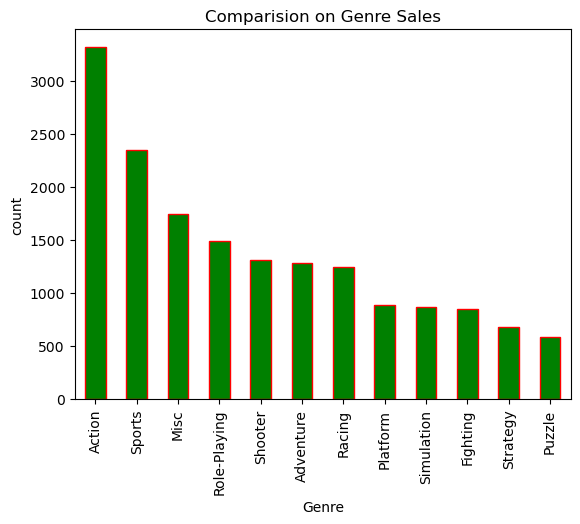

In [18]:
data['Genre'].value_counts().plot(kind='bar',color='Green',edgecolor='Red')
plt.title('Comparision on Genre Sales')
plt.xlabel('Genre')
plt.ylabel('count')
plt.show()

- Comparitively `Action` and `Sports` has the highest sales
---

## TOP 10 GAMING PLATFORMS (HAVING HIGH SALES) 

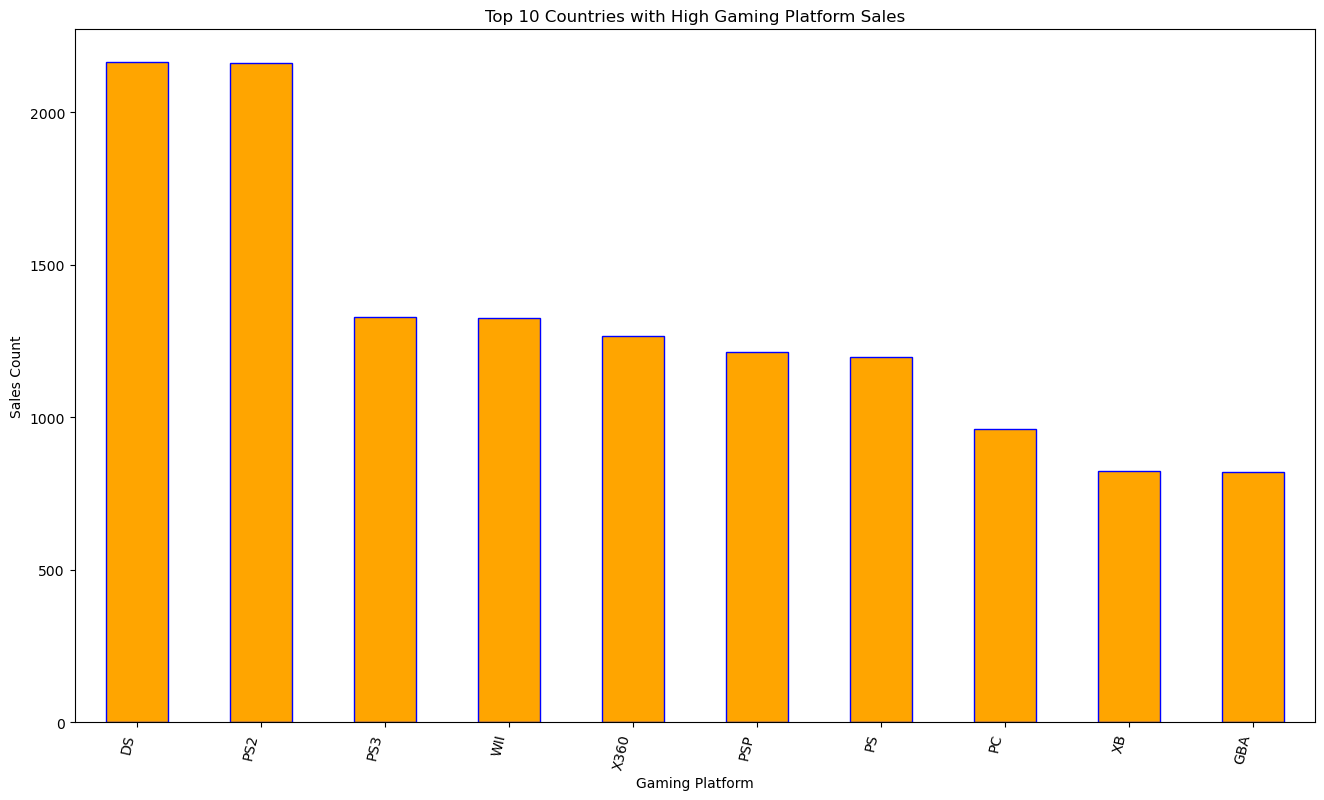

In [19]:
Platform_sales=data['Platform'].value_counts().head(10)
plt.figure(figsize=(16,9))
Platform_sales.plot(kind='bar',color='orange',edgecolor='blue')
plt.title("Top 10 Countries with High Gaming Platform Sales")
plt.ylabel('Sales Count')
plt.xlabel('Gaming Platform')
plt.xticks(rotation=77,ha='right')
plt.show()

---
## YEAR-WISE GAME SALES

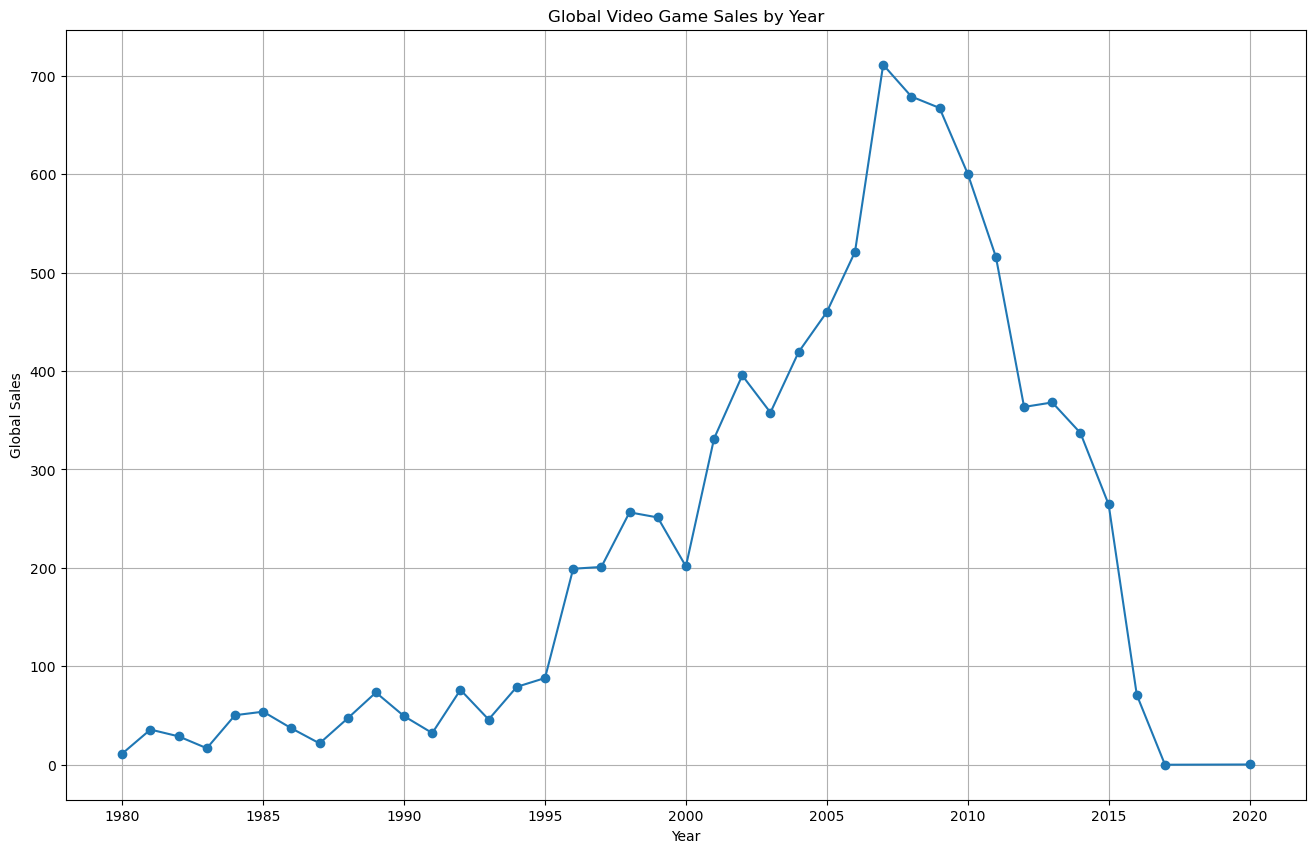

In [20]:
year_sales = data.groupby('Year')['Global_Sales'].sum().reset_index()
plt.figure(figsize=(16,10))
plt.plot(year_sales['Year'], year_sales['Global_Sales'], marker='o')
plt.title('Global Video Game Sales by Year')
plt.xlabel('Year')
plt.ylabel('Global Sales')
plt.grid(True)
plt.show()

---
## PERCENTAGE OF DIFFERENT GENRES (PIE-CHART)

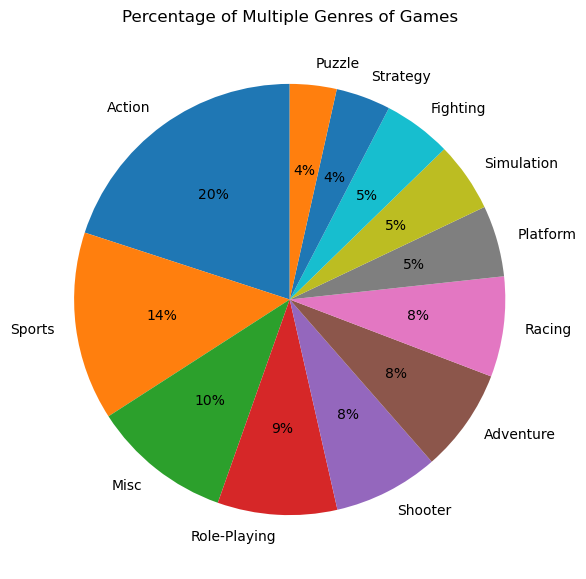

In [21]:
types=data['Genre'].value_counts()
plt.figure(figsize=(14,7))
types.plot(kind='pie',autopct='%1.f%%',startangle=90)
plt.title("Percentage of Multiple Genres of Games")
plt.ylabel('')
plt.show()

---
## DISTRIBUTION OF ACTION GAME SALES

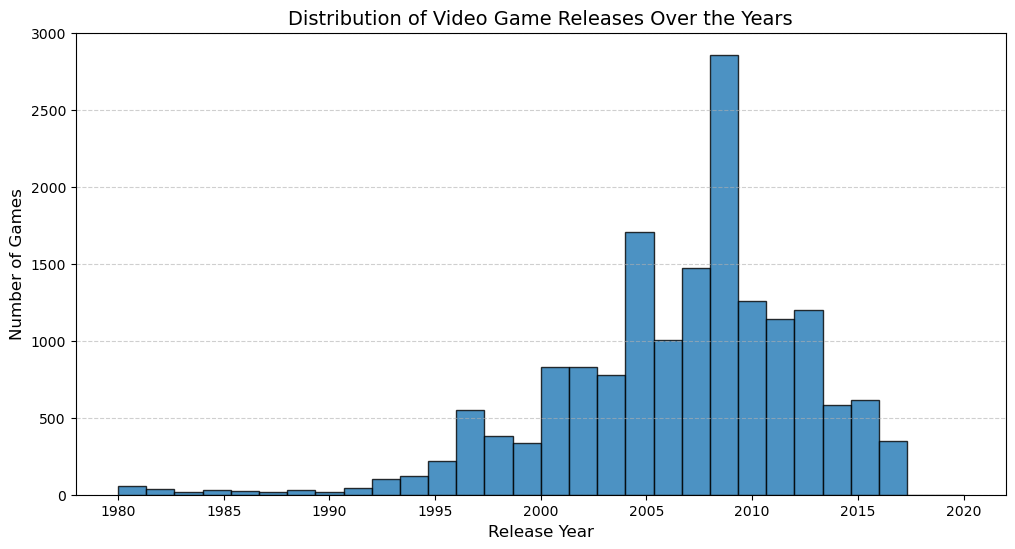

In [22]:
# Histogram without Seaborn

peak_year = data['Year'].mode()[0]
plt.figure(figsize=(12, 6))
plt.hist(data['Year'].dropna(),bins=30,edgecolor='black',alpha=0.8)

plt.title('Distribution of Video Game Releases Over the Years', fontsize=14)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Games', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

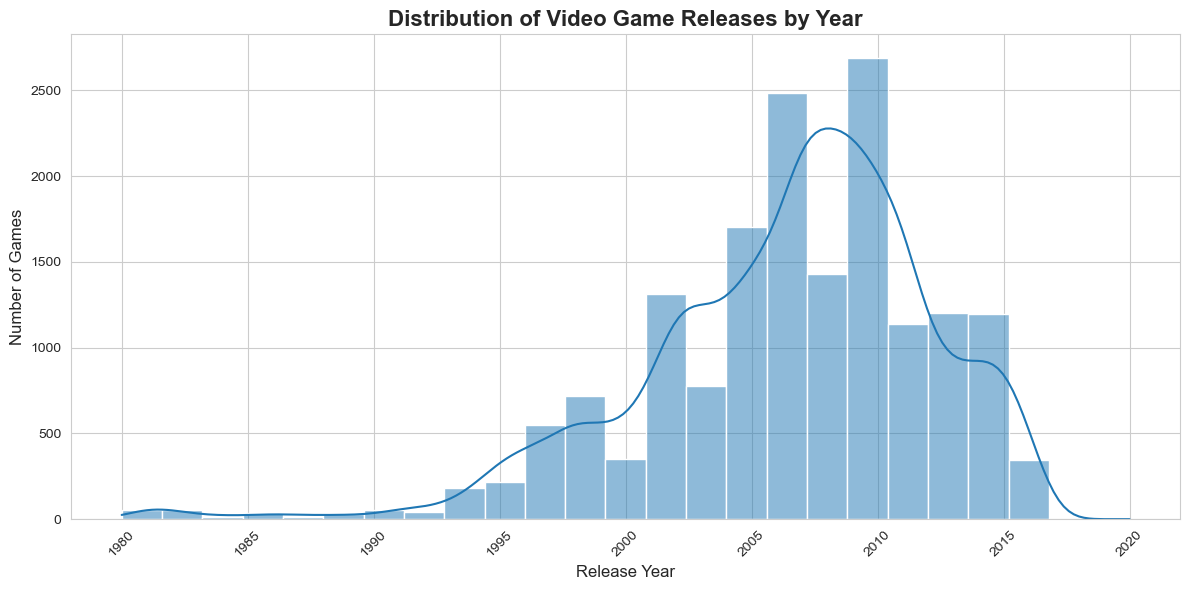

In [23]:
#Histogram with SeaBorn Style

sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

sns.histplot(data=data,x='Year',bins=25,kde=True)

# Titles and Labels
plt.title('Distribution of Video Game Releases by Year', fontsize=16, fontweight='bold')
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Games', fontsize=12)

# Improve layout
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

---
## RELATION BETWEEN SALES OF DIFFERENT REGIONS

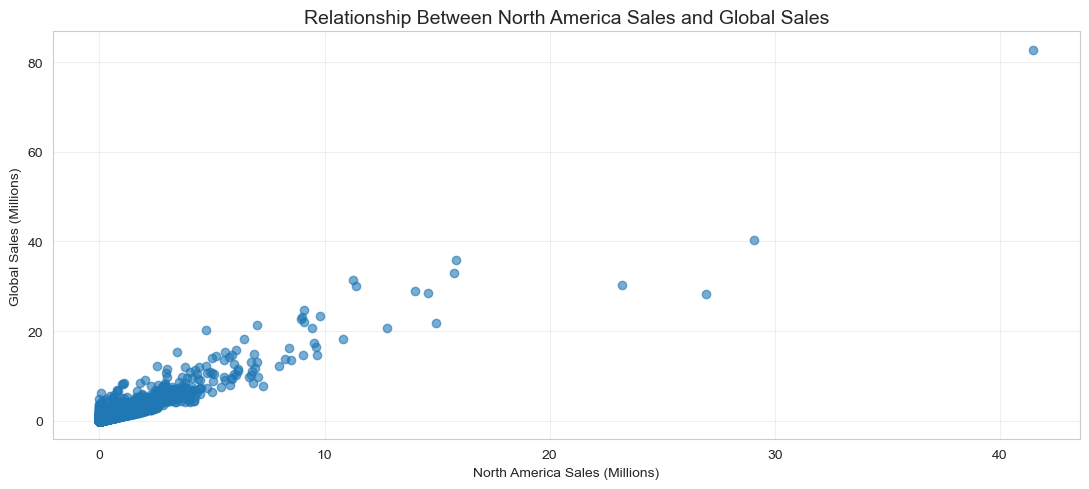

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

game_data = data[['NA_Sales', 'Global_Sales']].copy()

plt.figure(figsize=(11,5))
plt.scatter(game_data['NA_Sales'],game_data['Global_Sales'],alpha=0.6)

plt.title('Relationship Between North America Sales and Global Sales',fontsize=14)
plt.xlabel('North America Sales (Millions)')
plt.ylabel('Global Sales (Millions)')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
### 📊 Insight

- There is a strong positive relationship between North America Sales and Global Sales.
- Games with higher sales in North America generally achieve higher worldwide sales.
- A few blockbuster games appear as outliers with exceptionally high sales.